In [1]:
# imports
import pandas as pd
import matplotlib as plt

# display options
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# helper functions
def billions_formatter(x, pos):
    return f"{x * 1e-9:,.1f}B"


def plotBudget(df, title):
    trimmed = df.drop(
        columns=[
            "deptNum",
            "fundCode",
            "category",
            "appropriationAccount",
            "appropriationAuthority",
        ]
    )

    amounts = pd.DataFrame()
    amounts["local"] = (
        trimmed[trimmed["fundType"] == "LOCAL"].drop(columns=["fundType"]).sum()
    )
    amounts["grant"] = (
        trimmed[trimmed["fundType"] != "LOCAL"].drop(columns=["fundType"]).sum()
    )
    amounts
    ax = amounts.plot.area()
    ax.yaxis.set_major_formatter(plt.ticker.FuncFormatter(billions_formatter))
    ax.set_title(f"{title} Budget")
    ax.plot()

In [3]:
df = pd.read_csv("../../data/ordinance.csv")
fundsDf = pd.read_csv("../../data/funds.csv", index_col="fundNum")
deptsDf = pd.read_csv("../../data/depts.csv", index_col="deptNum")

df["fundType"] = df["fundCode"].apply(
    lambda x: fundsDf[fundsDf.index == x]["fundType"].iloc[0]
)
df["category"] = df["deptNum"].apply(
    lambda x: deptsDf[deptsDf.index == x]["category"].iloc[0]
)
df.head()

,deptNum,fundCode,appropriationAccount,appropriationAuthority,2011,2012,2013,2014,2015,2016,...,2019,2020,2021,2022,2023,2024,2025,2026,fundType,category
0,1,0100,0005,2005,5892558.00,5142155.00,5366703.00,5511957.00,5550657.00,5965114.00,...,7028929.00,9389344.00,9235579.00,10206075.00,10514517.00,11370347.00,10692655.00,10707977.00,LOCAL,Finance & Administration
1,1,0100,0030,2005,-519910.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,LOCAL,Finance & Administration
2,1,0100,0039,2005,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,298400.00,149200.00,180200.00,180200.00,249060.00,260000.00,57490.00,LOCAL,Finance & Administration
3,1,0100,0126,2005,1310.00,1200.00,1200.00,1200.00,1000.00,1000.00,...,1200.00,1600.00,1600.00,1600.00,1600.00,1600.00,3200.00,1500.00,LOCAL,Finance & Administration
4,1,0100,0130,2005,30918.00,23400.00,18000.00,10000.00,5019.00,5693.00,...,5000.00,5500.00,5500.00,5500.00,5500.00,5500.00,1600.00,500.00,LOCAL,Finance & Administration


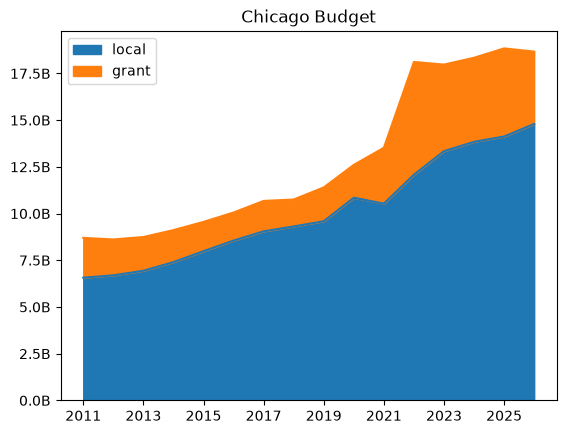

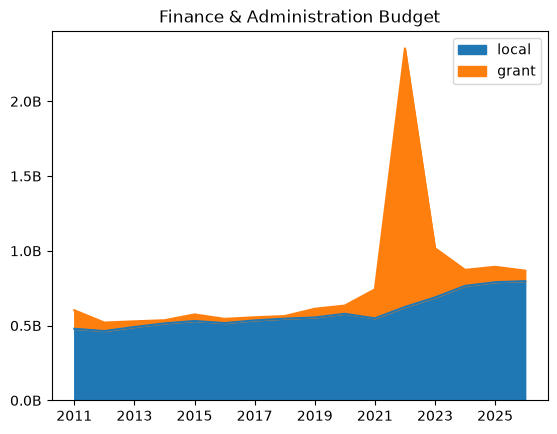

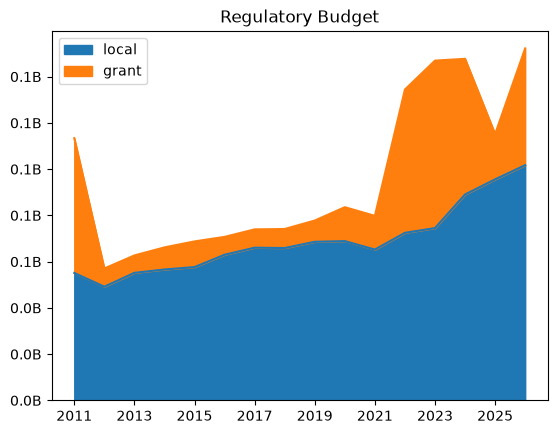

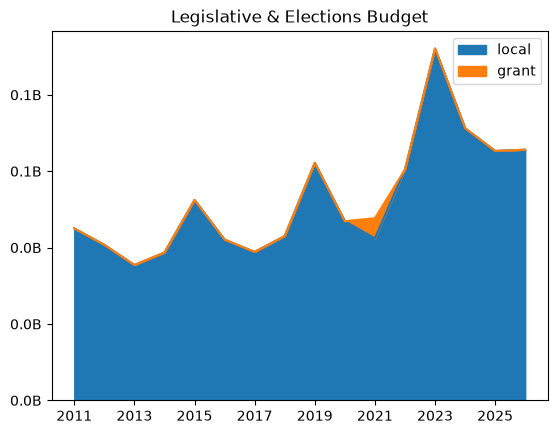

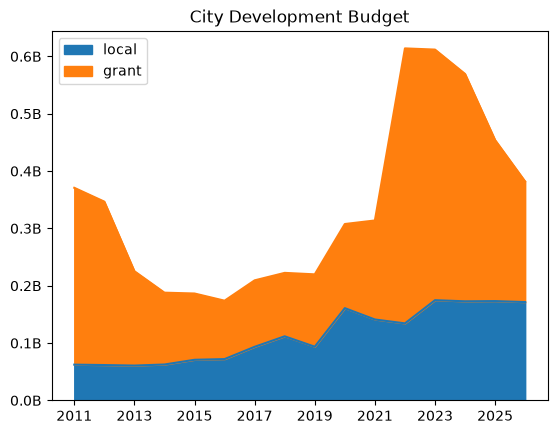

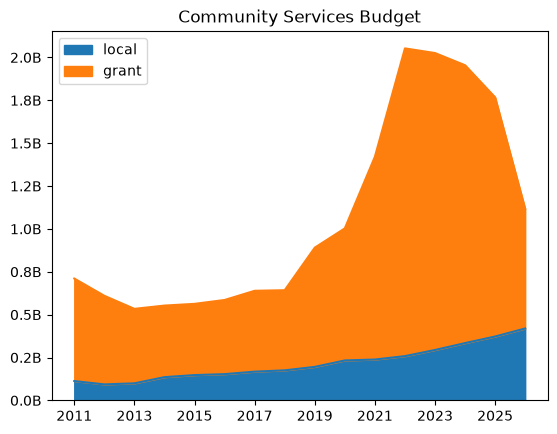

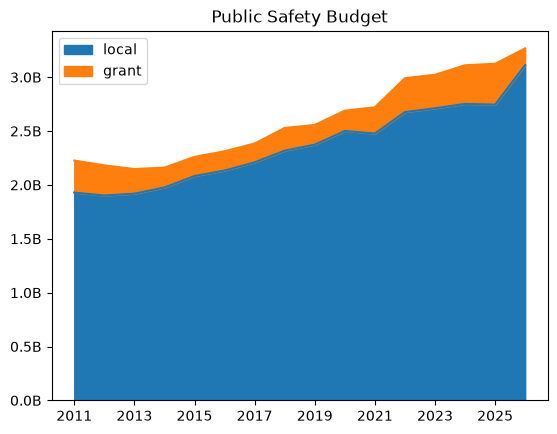

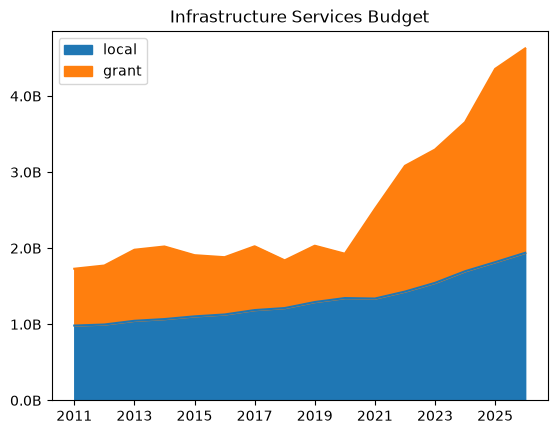

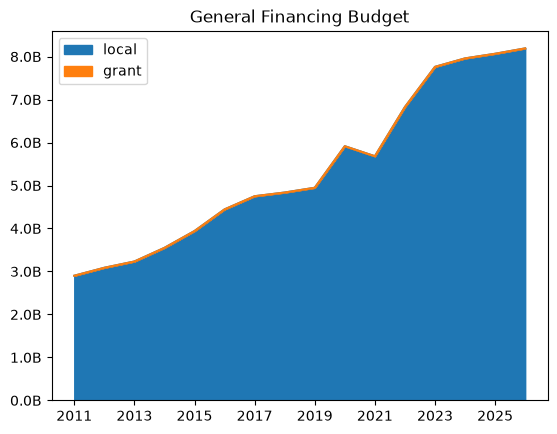

In [4]:
# helper consts
categories = df["category"].unique()

plotBudget(df, "Chicago")

for category in categories.unique():
    plotBudget(df[df["category"] == category], category)

In [ ]:
df[df["2026"] > 0][
   [
    "category",
    "deptNum",
    "appropriationAccount",
    "fundType",
    "fundCode",
    "2026"]
].sort_values(by=[
    "deptNum",
    "appropriationAccount",
    "fundType",
    "fundCode",]).reset_index(drop=True).head(10)

,category,deptNum,appropriationAccount,fundType,fundCode,2026
0,Finance & Administration,1,0005,GRANTS,925L,95867.00
1,Finance & Administration,1,0005,GRANTS,925L,172505.00
2,Finance & Administration,1,0005,GRANTS,GA00,106529.00
3,Finance & Administration,1,0005,LOCAL,0100,10707977.00
4,Finance & Administration,1,0005,LOCAL,0355,470873.00
5,Finance & Administration,1,0005,LOCAL,0B21,124909.00
6,Finance & Administration,1,0005,LOCAL,0B70,806222.00
7,Finance & Administration,1,0006,GRANTS,925L,45827.00
8,Finance & Administration,1,0006,GRANTS,GA00,1013.00
9,Finance & Administration,1,0039,LOCAL,0100,57490.00
